In [1]:
import warnings
import sys 
import os    
import glob
from statesegmentation import GSBS
from functools import reduce
import numpy as np
from brainiak.eventseg.event import EventSegment
import nibabel as nib
from nilearn.masking import apply_mask
from nltools.data import Brain_Data
from scipy.stats import zscore, norm
import datalad.api as dl

from matplotlib import pyplot as plt
import matplotlib.patches as patches
%matplotlib inline

smallsize=14; mediumsize=16; largesize=18
plt.rc('xtick', labelsize=smallsize); plt.rc('ytick', labelsize=smallsize); plt.rc('legend', fontsize=mediumsize)
plt.rc('figure', titlesize=largesize); plt.rc('axes', labelsize=mediumsize); plt.rc('axes', titlesize=mediumsize)

In [2]:
data_dir =  "/Users/saman/Downloads/12436955"

In [3]:
movie = np.load(data_dir + '/Sherlock_AG_movie.npy', allow_pickle=True)
recall = np.load(data_dir + '/Sherlock_AG_recall.npy', allow_pickle=True)
movie_group = np.mean(movie, axis=0)

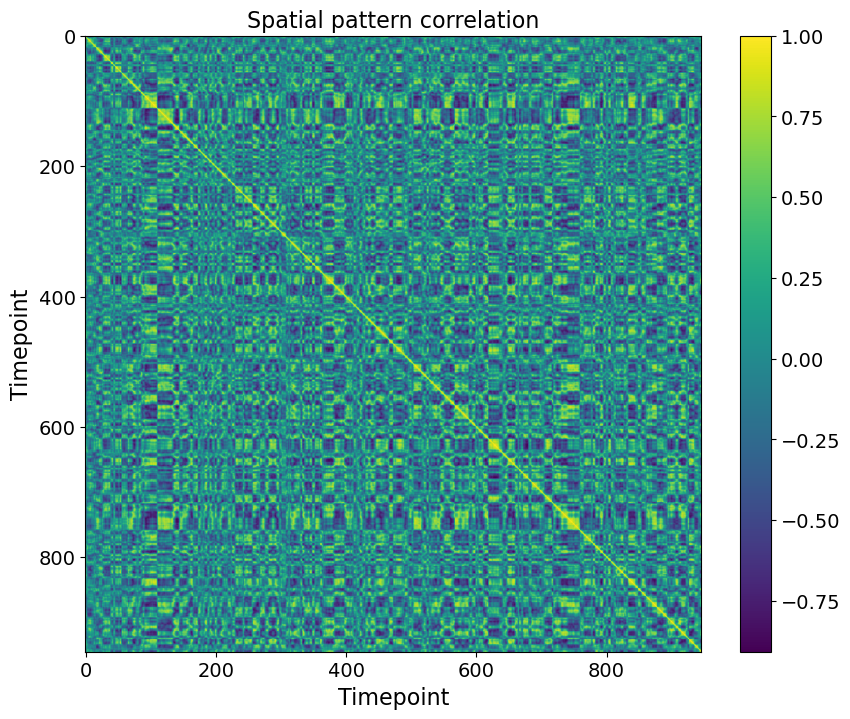

In [4]:
plt.figure(figsize=(10,8))
plt.imshow(np.corrcoef(movie_group))
plt.xlabel('Timepoint')
plt.ylabel('Timepoint')
plt.colorbar()
plt.title('Spatial pattern correlation');

In [5]:
movie_HMM = EventSegment(n_events = 29)
movie_HMM.fit(movie_group);

Text(0.5, 0, 'Model fitting steps')

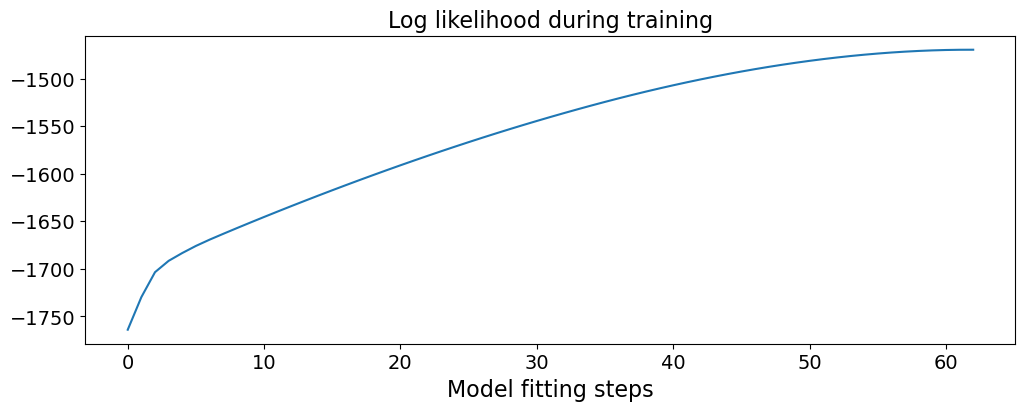

In [6]:
# Plotting the log-likelihood (measuring overall model fit)
plt.figure(figsize = (12, 4))
plt.plot(movie_HMM.ll_)
plt.title('Log likelihood during training')
plt.xlabel('Model fitting steps')

Text(0, 0.5, 'Voxels')

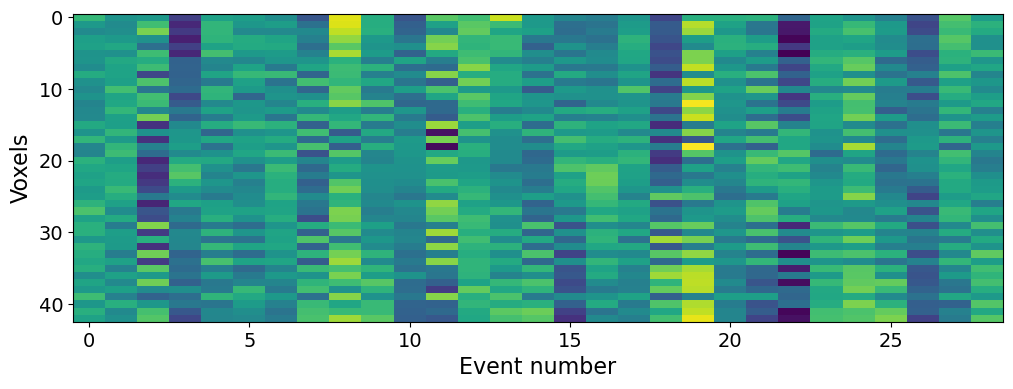

In [7]:
# Plotting mean activity in each event for some example voxels
plt.figure(figsize = (12, 4))
example_vox = np.arange(0,movie_HMM.event_pat_.shape[0],100)
plt.imshow(movie_HMM.event_pat_[example_vox,:], aspect='auto')
plt.xlabel('Event number')
plt.ylabel('Voxels')

Text(0.5, 1.0, 'Event probability')

<Figure size 1200x600 with 0 Axes>

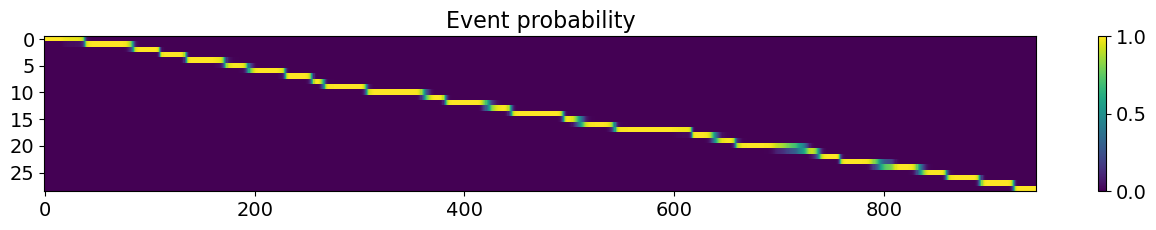

In [8]:
# Plot probability of being in each event at each timepoint
plt.figure(figsize = (12, 6))
plt.matshow(movie_HMM.segments_[0].T, aspect='auto')
plt.gca().xaxis.tick_bottom()
plt.colorbar()
plt.title('Event probability')

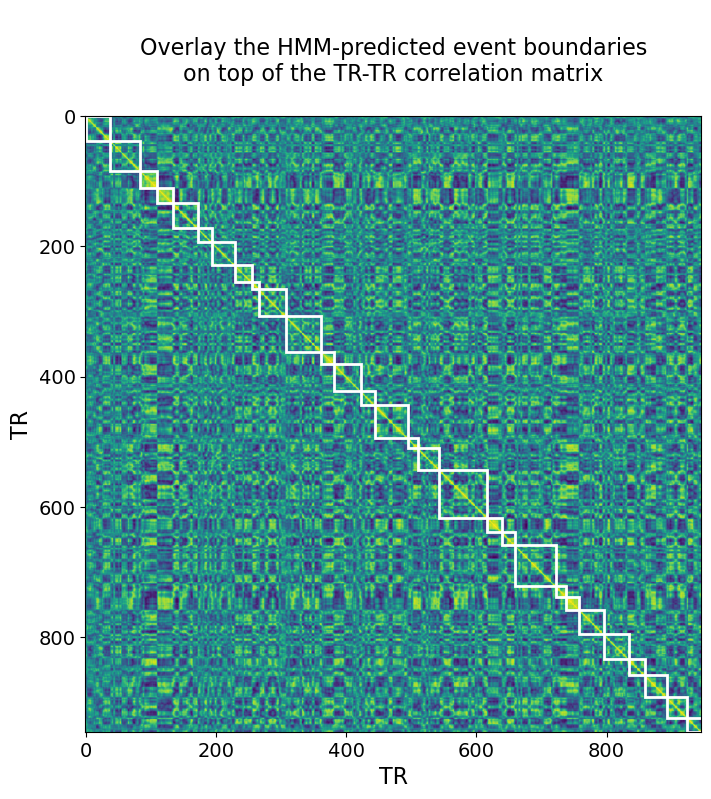

In [9]:
# Identify event boundaries as timepoints when max probability switches events
event_bounds = np.where(np.diff(np.argmax(movie_HMM.segments_[0], axis = 1)))[0]
nTRs = movie_group.shape[0]


# Plot boundaries as boxes on top of timepoint correlation matrix
def plot_tt_similarity_matrix(ax, data_matrix, bounds, n_TRs, title_text):
    
    ax.imshow(np.corrcoef(data_matrix), cmap = 'viridis')
    ax.set_title(title_text)
    ax.set_xlabel('TR')
    ax.set_ylabel('TR')
    
    # plot the boundaries 
    bounds_aug = np.concatenate(([0], bounds, [n_TRs]))
    
    for i in range(len(bounds_aug) - 1):
        rect = patches.Rectangle(
            (bounds_aug[i], bounds_aug[i]),
            bounds_aug[i+1] - bounds_aug[i],
            bounds_aug[i+1] - bounds_aug[i],
            linewidth = 2, edgecolor = 'w',facecolor = 'none'
        )
        ax.add_patch(rect)


f, ax = plt.subplots(1,1, figsize = (10,8))
title_text = '''
Overlay the HMM-predicted event boundaries
on top of the TR-TR correlation matrix
'''
plot_tt_similarity_matrix(ax, movie_group, event_bounds, nTRs, title_text)

In [10]:
k_array = np.arange(20, 61, 10)
test_ll = np.zeros(len(k_array))

for i, k in enumerate(k_array):
    print('Trying %d events' % k)
    
    print('   Fitting model on training subjects...')
    movie_train = np.mean(movie[:8], axis = 0)
    movie_HMM = EventSegment(k)
    movie_HMM.fit(movie_train)
    
    print('   Testing model fit on held-out subjects...')
    movie_test = np.mean(movie[8:], axis = 0)
    _, test_ll[i] = movie_HMM.find_events(movie_test)

Trying 20 events
   Fitting model on training subjects...
   Testing model fit on held-out subjects...
Trying 30 events
   Fitting model on training subjects...
   Testing model fit on held-out subjects...
Trying 40 events
   Fitting model on training subjects...
   Testing model fit on held-out subjects...
Trying 50 events
   Fitting model on training subjects...
   Testing model fit on held-out subjects...
Trying 60 events
   Fitting model on training subjects...
   Testing model fit on held-out subjects...


Text(0.5, 0, 'Average event length (sec)')

C:\Users\saman\AppData\Local\Temp\ipykernel_19556\2352970205.py:6: RuntimeWarning: divide by zero encountered in divide
  secax = plt.gca().secondary_xaxis('top', functions=(lambda x: movie_dur / x, lambda x: movie_dur / x))


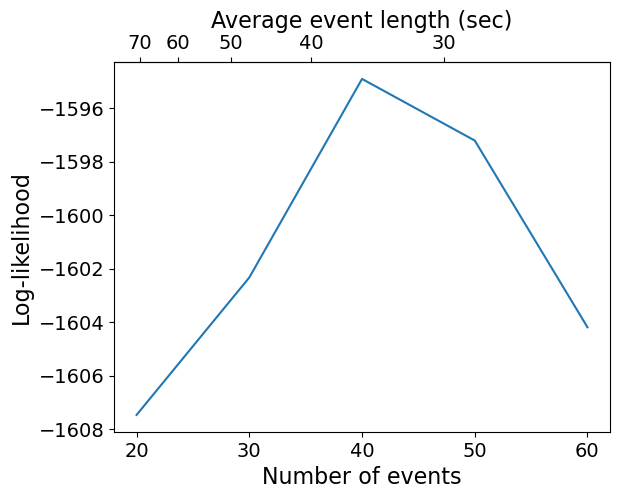

In [11]:
plt.plot(k_array, test_ll)
plt.xlabel('Number of events')
plt.ylabel('Log-likelihood')

movie_dur = nTRs * 1.5  # Data acquired every 1.5 seconds
secax = plt.gca().secondary_xaxis('top', functions=(lambda x: movie_dur / x, lambda x: movie_dur / x))
secax.set_xlabel('Average event length (sec)')

In [ ]:
print('Fitting HMM with 40 events...')
HMM40 = EventSegment(n_events = 40)
HMM40.fit(movie_group)
HMM40_bounds = np.where(np.diff(np.argmax(HMM40.segments_[0], axis = 1)))[0]

print('Fitting split-merge HMM with 40 events...')
HMM40_SM = EventSegment(n_events = 40, split_merge = True)
HMM40_SM.fit(movie_group)
HMM40_SM_bounds = np.where(np.diff(np.argmax(HMM40_SM.segments_[0], axis = 1)))[0]

Fitting HMM with 40 events...


In [ ]:
GSBS_states = GSBS(x = movie_group, kmax = 140)
GSBS_states.fit()